# 05 - Segmentation, Cutoff & Profitability Analysis

- Customer segmentation theo dai risk score (3-5 nhom)
- Cutoff analysis: approval rate, bad rate, Expected Net Return
- Business rules override
- Chuan bi du lieu cho Dashboard

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from src.paths import DATA_RAW, DATA_INTERIM, DATA_PROCESSED, MODELS, REPORTS_FIGURES, DASHBOARDS

## Segmentation theo risk score

In [2]:
import numpy as np
import pickle
from scipy.stats import chi2_contingency

test_df = pd.read_parquet(DATA_PROCESSED / 'test.parquet')

with open(MODELS / 'primary_model.txt') as f:
    primary_model_name = f.read().strip()
print('Model chinh:', primary_model_name)

WOE_FEATURES = [c for c in test_df.columns if c.endswith('_woe')]
RAW_FEATURES = [c[:-4] for c in WOE_FEATURES]

if primary_model_name == 'LightGBM':
    import lightgbm as lgb
    gbm = lgb.Booster(model_file=str(MODELS / 'lightgbm_model.txt'))
    cat_features = [c for c in RAW_FEATURES if not pd.api.types.is_numeric_dtype(test_df[c])]
    X_score = test_df[RAW_FEATURES].copy()
    for c in cat_features:
        X_score[c] = X_score[c].astype('category')
    score = gbm.predict(X_score)  # score = P(bad) - cao hon = rui ro cao hon
else:
    with open(MODELS / 'logistic_regression_woe.pkl', 'rb') as f:
        lr = pickle.load(f)
    score = lr.predict_proba(test_df[WOE_FEATURES])[:, 1]

test_df = test_df.copy()
test_df['pd_score'] = score  # xac suat du bao default, cang cao cang rui ro

# Segmentation: chia 5 nhom theo quantile cua pd_score (nhom 1 = rui ro thap nhat)
N_SEGMENTS = 5
test_df['segment'] = pd.qcut(test_df['pd_score'], N_SEGMENTS, labels=[f'S{i+1}' for i in range(N_SEGMENTS)])

segment_summary = test_df.groupby('segment', observed=True).agg(
    n=('bad_flag', 'size'),
    bad_rate=('bad_flag', 'mean'),
    avg_pd_score=('pd_score', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
).reset_index()
print(segment_summary.to_string(index=False))

# Kiem dinh chi-square: default rate co tach biet co y nghia thong ke giua cac segment khong
contingency = pd.crosstab(test_df['segment'], test_df['bad_flag'])
chi2, p_value, _, _ = chi2_contingency(contingency)
print(f'\nChi-square segment vs bad_flag: chi2={chi2:.2f}, p={p_value:.6f}')
print('-> Default rate tach biet co y nghia thong ke giua cac segment.' if p_value < 0.05
      else '-> CANH BAO: khong co bang chung default rate khac biet giua cac segment.')


Model chinh: Logistic Regression + WOE


segment     n  bad_rate  avg_pd_score  avg_loan_amnt  avg_int_rate
     S1 21041  0.085595      0.067272   14505.046100      8.714885
     S2 21041  0.144813      0.111981   13092.172425     11.497681
     S3 21040  0.198432      0.147887   11969.720770     13.167582
     S4 21041  0.246043      0.187341   10904.165677     14.349387
     S5 21041  0.322228      0.260789    9979.955801     15.959378

Chi-square segment vs bad_flag: chi2=4374.80, p=0.000000
-> Default rate tach biet co y nghia thong ke giua cac segment.


## Cutoff / profitability analysis

LGD thuc te (1 - von goc thu hoi / von goc giai ngan, cac khoan Charged Off vintage 2015-2017): 58.87%



Tai approval rate ~79.4%: bad rate theo score = 16.81% vs. bad rate duyet ngau nhien (= bad rate quan the) = 19.94%

De xuat cutoff (toi da hoa Expected Net Return tren tap test): pd_score <= 0.11
cutoff                         1.100000e-01
approval_rate                  2.882210e-01
n_approved                     3.032200e+04
bad_rate_approved              9.982851e-02
interest_income                3.560382e+07
expected_loss                  2.915845e+07
expected_net_return            6.445368e+06
random_net_return             -5.657844e+06
net_return_uplift_vs_random    1.210321e+07


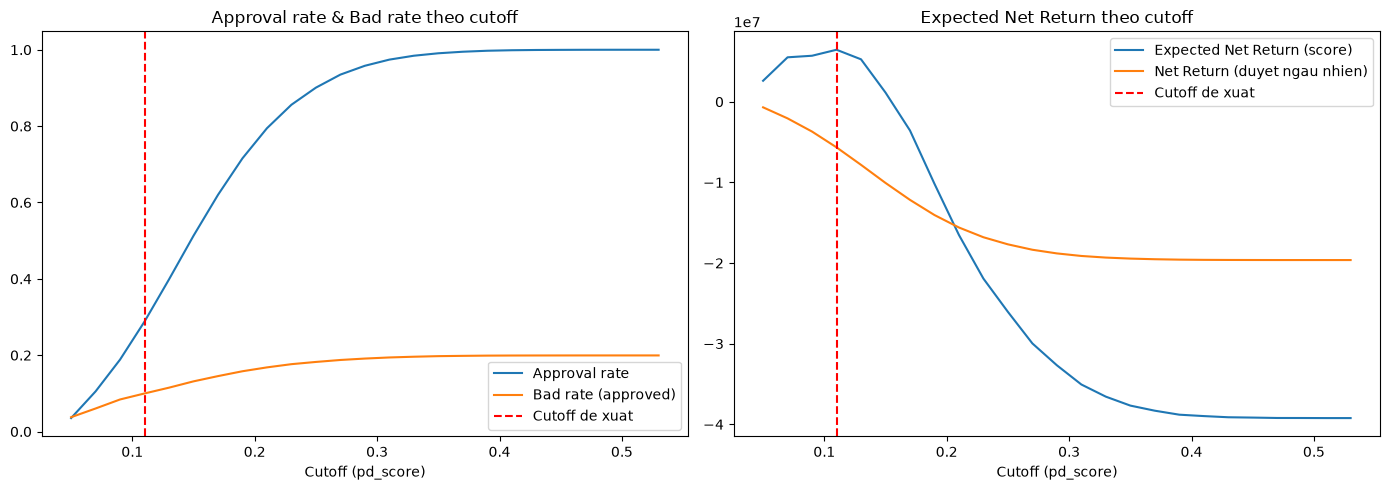

In [3]:
import matplotlib.pyplot as plt
from src.data.filter_vintage import filter_vintage
from src.paths import ACCEPTED_RAW

# --- LGD thuc te (aggregate, KHONG dung lam feature model - xem BRD.md muc 4 / PROPOSAL 4.3:
# chi cam dung leakage columns lam PREDICTOR, khong cam do luong outcome tai chinh thuc te) ---
usecols = ['loan_amnt', 'funded_amnt', 'term', 'issue_d', 'loan_status', 'total_rec_prncp', 'recoveries']
raw_chunks = [filter_vintage(chunk) for chunk in pd.read_csv(
    ACCEPTED_RAW, usecols=usecols, chunksize=200_000, low_memory=False
)]
raw_outcome = pd.concat(raw_chunks, ignore_index=True)

charged_off = raw_outcome[raw_outcome['loan_status'] == 'Charged Off']
total_funded = charged_off['funded_amnt'].sum()
total_principal_recovered = (charged_off['total_rec_prncp'] + charged_off['recoveries']).sum()
LGD = float(np.clip(1 - total_principal_recovered / total_funded, 0, 1))
print(f'LGD thuc te (1 - von goc thu hoi / von goc giai ngan, cac khoan Charged Off vintage 2015-2017): {LGD:.2%}')

# --- Cutoff sweep: duyet neu pd_score <= cutoff (thap = it rui ro hon) ---
# Expected Net Return = Sigma(int_rate x loan_amnt, nhom Good duoc duyet) - Sigma(loan_amnt x LGD,
# nhom Bad duoc duyet) theo dung cong thuc PROPOSAL muc 5.2. Don gian hoa: int_rate ap dung 1 lan
# (khong nhan them so nam ky han) - dung nguyen van cong thuc de xuat trong PROPOSAL.
n_total = len(test_df)
baseline_bad_rate = test_df['bad_flag'].mean()
avg_int_rate = test_df['int_rate'].mean() / 100
avg_loan_amnt = test_df['loan_amnt'].mean()

rows = []
for cutoff in np.arange(0.05, 0.55, 0.02):
    approved = test_df[test_df['pd_score'] <= cutoff]
    if len(approved) == 0:
        continue
    good = approved[approved['bad_flag'] == 0]
    bad = approved[approved['bad_flag'] == 1]
    interest_income = (good['int_rate'] / 100 * good['loan_amnt']).sum()
    expected_loss = (bad['loan_amnt'] * LGD).sum()
    n_approved = len(approved)
    random_net_return = n_approved * (
        (1 - baseline_bad_rate) * avg_int_rate * avg_loan_amnt - baseline_bad_rate * avg_loan_amnt * LGD
    )
    rows.append({
        'cutoff': round(cutoff, 2),
        'approval_rate': n_approved / n_total,
        'n_approved': n_approved,
        'bad_rate_approved': approved['bad_flag'].mean(),
        'interest_income': interest_income,
        'expected_loss': expected_loss,
        'expected_net_return': interest_income - expected_loss,
        'random_net_return': random_net_return,
    })

cutoff_table = pd.DataFrame(rows)
cutoff_table['net_return_uplift_vs_random'] = (
    cutoff_table['expected_net_return'] - cutoff_table['random_net_return']
)

target_approval = 0.80
idx_80 = (cutoff_table['approval_rate'] - target_approval).abs().idxmin()
row_80 = cutoff_table.loc[idx_80]
print(f"\nTai approval rate ~{row_80['approval_rate']:.1%}: bad rate theo score = "
      f"{row_80['bad_rate_approved']:.2%} vs. bad rate duyet ngau nhien (= bad rate quan the) = "
      f"{baseline_bad_rate:.2%}")

best_idx = cutoff_table['expected_net_return'].idxmax()
recommended = cutoff_table.loc[best_idx]
print(f"\nDe xuat cutoff (toi da hoa Expected Net Return tren tap test): pd_score <= {recommended['cutoff']}")
print(recommended.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cutoff_table['cutoff'], cutoff_table['approval_rate'], label='Approval rate')
axes[0].plot(cutoff_table['cutoff'], cutoff_table['bad_rate_approved'], label='Bad rate (approved)')
axes[0].axvline(recommended['cutoff'], color='red', linestyle='--', label='Cutoff de xuat')
axes[0].set_xlabel('Cutoff (pd_score)')
axes[0].legend()
axes[0].set_title('Approval rate & Bad rate theo cutoff')

axes[1].plot(cutoff_table['cutoff'], cutoff_table['expected_net_return'], label='Expected Net Return (score)')
axes[1].plot(cutoff_table['cutoff'], cutoff_table['random_net_return'], label='Net Return (duyet ngau nhien)')
axes[1].axvline(recommended['cutoff'], color='red', linestyle='--', label='Cutoff de xuat')
axes[1].set_xlabel('Cutoff (pd_score)')
axes[1].legend()
axes[1].set_title('Expected Net Return theo cutoff')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'cutoff_profitability_analysis.png', dpi=100)
plt.show()

cutoff_table.to_csv(REPORTS_FIGURES / 'cutoff_table.csv', index=False)


## Business rules

In [4]:
# Business rules dua tren IV tinh tren TAP TRAIN (iv_table_train.csv tu notebook 03), khong
# dung iv_table.csv (fit tren toan bo vintage, gom ca ky test - xem rui ro R5).
# Chi chon bien numeric co the dat threshold nghiep vu ro rang (loai categorical nhu addr_state).
iv_table_train = pd.read_csv(REPORTS_FIGURES / 'iv_table_train.csv')
RULE_CANDIDATES = ['dti', 'revol_util', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec',
                   'credit_history_length', 'open_acc', 'total_acc', 'revol_bal']
rule_iv = iv_table_train[
    iv_table_train['name'].isin(RULE_CANDIDATES)
    & iv_table_train['name'].isin(test_df.columns)
].sort_values('iv', ascending=False)
print(rule_iv[['name', 'iv']].to_string(index=False))

top_rule_vars = rule_iv['name'].head(2).tolist()
print('\nBien duoc chon cho Business Rules:', top_rule_vars)

# Threshold = percentile 95 tren tap test - phan duoi cung ve rui ro, danh dau bat buoc Review
rules = []
for var in top_rule_vars:
    threshold = float(test_df[var].quantile(0.95))
    flagged = test_df[var] > threshold
    rules.append({
        'variable': var,
        'threshold': round(threshold, 2),
        'rule': f'{var} > {threshold:.1f} -> bat buoc Review du score tot',
        'pct_population_flagged': flagged.mean(),
        'bad_rate_flagged': test_df.loc[flagged, 'bad_flag'].mean(),
        'bad_rate_overall': test_df['bad_flag'].mean(),
    })

business_rules = pd.DataFrame(rules)
business_rules['uplift_vs_overall'] = business_rules['bad_rate_flagged'] - business_rules['bad_rate_overall']
print(business_rules.to_string(index=False))
business_rules.to_csv(REPORTS_FIGURES / 'business_rules.csv', index=False)


                 name       iv
                  dti 0.063926
       inq_last_6mths 0.049900
credit_history_length 0.022695
            revol_bal 0.020078
           revol_util 0.014640
              pub_rec 0.010201
            total_acc 0.004620
          delinq_2yrs 0.002626
             open_acc 0.001954

Bien duoc chon cho Business Rules: ['dti', 'inq_last_6mths']
      variable  threshold                                                 rule  pct_population_flagged  bad_rate_flagged  bad_rate_overall  uplift_vs_overall
           dti      33.14           dti > 33.1 -> bat buoc Review du score tot                0.049884          0.279535          0.199422           0.080113
inq_last_6mths       2.00 inq_last_6mths > 2.0 -> bat buoc Review du score tot                0.038069          0.290886          0.199422           0.091464


## Export du lieu cho Dashboard

In [5]:
DASHBOARDS.mkdir(parents=True, exist_ok=True)

# Recommendation per-loan: Approve / Review / Reject theo cutoff de xuat + business rules override
def recommend(row):
    rule_hit = any(row[r['variable']] > r['threshold'] for r in rules)
    if rule_hit:
        return 'Review'
    if row['pd_score'] <= recommended['cutoff']:
        return 'Approve'
    return 'Reject'

test_df['recommendation'] = test_df.apply(recommend, axis=1)
print(test_df['recommendation'].value_counts(normalize=True))

# 1) Risk & Portfolio Dashboard
segment_summary.to_csv(DASHBOARDS / 'segment_summary.csv', index=False)
cutoff_table.to_csv(DASHBOARDS / 'cutoff_table.csv', index=False)
business_rules.to_csv(DASHBOARDS / 'business_rules.csv', index=False)
# Xep hang yeu to rui ro: xuat ca 2 ban - IV tren train (dung cho model) va IV tren toan bo
# vintage (dung tra loi RQ1 "yeu to nao anh huong manh nhat" tren toan danh muc).
iv_table_train.to_csv(DASHBOARDS / 'iv_ranking_train.csv', index=False)
pd.read_csv(REPORTS_FIGURES / 'iv_table.csv').to_csv(DASHBOARDS / 'iv_ranking.csv', index=False)

# 2) Customer Dashboard - 1 dong / khach hang: profile + score + segment + recommendation.
# Notebook 03 nay giu lai toan bo bien ung vien (khong chi shortlist) nen purpose/addr_state
# da co san de hien thi ho so, du chung khong duoc dua vao model.
customer_cols = [c for c in [
    'pd_score', 'segment', 'recommendation', 'loan_amnt', 'int_rate', 'grade',
    'fico_mid', 'dti', 'annual_inc', 'home_ownership', 'purpose', 'addr_state',
    'emp_length_years', 'credit_history_length', 'revol_util', 'inq_last_6mths',
] if c in test_df.columns]
test_df[customer_cols].to_csv(DASHBOARDS / 'customer_dashboard_data.csv', index=False)
print('\nCustomer dashboard columns:', customer_cols)

print('\nDa export du lieu tong hop vao dashboards/ (segment_summary, cutoff_table, iv_ranking,')
print('iv_ranking_train, business_rules, customer_dashboard_data).')


recommendation
Reject     0.631668
Approve    0.281871
Review     0.086461
Name: proportion, dtype: float64



Customer dashboard columns: ['pd_score', 'segment', 'recommendation', 'loan_amnt', 'int_rate', 'grade', 'fico_mid', 'dti', 'annual_inc', 'home_ownership', 'purpose', 'addr_state', 'emp_length_years', 'credit_history_length', 'revol_util', 'inq_last_6mths']

Da export du lieu tong hop vao dashboards/ (segment_summary, cutoff_table, iv_ranking,
iv_ranking_train, business_rules, customer_dashboard_data).
